<a href="https://colab.research.google.com/github/vaideheedaf/ML-Coral-reef/blob/main/ML_Coral_Reef_Health_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install & fetch dataset from Kaggle

In [ ]:
!pip install -q kagglehub scikit-image opencv-python-headless tqdm

In [ ]:
import kagglehub

# Downloads to Colab's disk (not your Drive, not your laptop)
path = kagglehub.dataset_download("asfarhossainsitab/coral-reefs-images")
print("Downloaded to:", path)

Using Colab cache for faster access to the 'coral-reefs-images' dataset.
Downloaded to: /kaggle/input/coral-reefs-images


In [ ]:
import os

def find_root(base):
    for dirpath, dirnames, _ in os.walk(base):
        if {"train", "test", "valid"} <= {d.lower() for d in dirnames}:
            return dirpath
    raise FileNotFoundError("Could not find train/test/valid folders")

ROOT = find_root(path)

def get_split_dir(split_name):
    return next(os.path.join(ROOT, d) for d in os.listdir(ROOT) if d.lower() == split_name)

print("Root:", ROOT)

Root: /kaggle/input/coral-reefs-images/Coral Reef Images


In [ ]:
import random, cv2, numpy as np

random.seed(42)
sample = []
for cls in sorted(os.listdir(get_split_dir("train"))):
    d = os.path.join(get_split_dir("train"), cls)
    files = random.sample(os.listdir(d), min(40, len(os.listdir(d))))
    sample += [(cls, os.path.join(d, f)) for f in files]

hsv_imgs = []
for cls, p in sample:
    im = cv2.imread(p)
    if im is None: continue
    hsv_imgs.append((cls, cv2.cvtColor(cv2.resize(im, (256, 256)), cv2.COLOR_BGR2HSV)))

print(f"{'S_MAX':>6} {'V_MIN':>6} | {'% imgs with 0':>13} | {'mean white% Bleached':>20} | {'mean white% Healthy':>19}")
for s_max in [30, 60, 90]:
    for v_min in [200, 180, 160]:
        vals = {"Bleached": [], "Healthy": []}
        for cls, hsv in hsv_imgs:
            m = (hsv[:, :, 1] < s_max) & (hsv[:, :, 2] > v_min)
            vals[cls.strip().capitalize()].append(m.mean() * 100)
        allv = vals["Bleached"] + vals["Healthy"]
        zero_pct = 100 * np.mean(np.array(allv) == 0)
        print(f"{s_max:>6} {v_min:>6} | {zero_pct:>12.1f}% | {np.mean(vals['Bleached']):>20.2f} | {np.mean(vals['Healthy']):>19.2f}")

 S_MAX  V_MIN | % imgs with 0 | mean white% Bleached | mean white% Healthy
    30    200 |         18.8% |                 3.37 |                0.40
    30    180 |         10.0% |                 5.10 |                0.60
    30    160 |          7.5% |                 6.74 |                0.76
    60    200 |          6.2% |                 5.42 |                1.22
    60    180 |          2.5% |                 8.80 |                1.98
    60    160 |          1.2% |                12.26 |                2.82
    90    200 |          2.5% |                 6.41 |                2.05
    90    180 |          1.2% |                10.51 |                3.41
    90    160 |          1.2% |                15.10 |                5.39


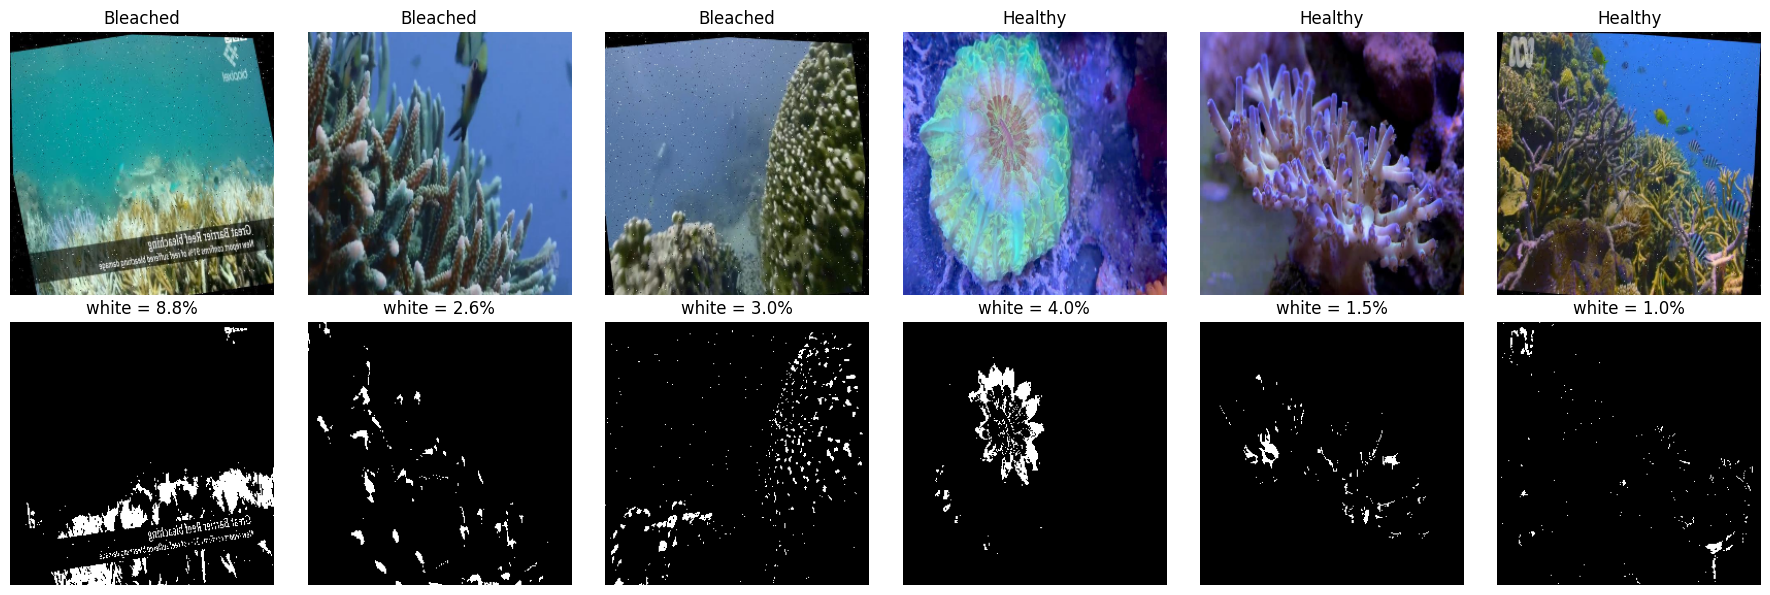

In [ ]:
import matplotlib.pyplot as plt

S_MAX_TRY, V_MIN_TRY = 60, 170

picks = [x for x in sample if x[0].lower().startswith("bleached")][:3] + \
        [x for x in sample if x[0].lower().startswith("healthy")][:3]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, (cls, p) in enumerate(picks):
    bgr = cv2.resize(cv2.imread(p), (256, 256))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask = (hsv[:, :, 1] < S_MAX_TRY) & (hsv[:, :, 2] > V_MIN_TRY)
    axes[0, i].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); axes[0, i].set_title(cls); axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray"); axes[1, i].set_title(f"white = {mask.mean()*100:.1f}%"); axes[1, i].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.measure import shannon_entropy

IMG_SIZE    = (256, 256)
WHITE_S_MAX = 60     # was 30 in v1
WHITE_V_MIN = 170    # was 200 in v1

def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE)

    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab  = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mean_saturation = hsv[:, :, 1].mean()
    mean_brightness = hsv[:, :, 2].mean()
    white_mask = (hsv[:, :, 1] < WHITE_S_MAX) & (hsv[:, :, 2] > WHITE_V_MIN)
    white_pixel_pct = white_mask.mean() * 100
    mean_lightness = lab[:, :, 0].mean()

    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp_mean = lbp.mean()

    glcm = graycomatrix(gray, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    glcm_contrast    = graycoprops(glcm, "contrast").mean()
    glcm_homogeneity = graycoprops(glcm, "homogeneity").mean()

    edges = cv2.Canny(gray, 100, 200)
    edge_density = (edges > 0).mean()
    entropy = shannon_entropy(gray)

    return {
        "mean_saturation": mean_saturation,
        "mean_brightness": mean_brightness,
        "white_pixel_pct": white_pixel_pct,
        "mean_lightness": mean_lightness,
        "lbp_mean": lbp_mean,
        "glcm_contrast": glcm_contrast,
        "glcm_homogeneity": glcm_homogeneity,
        "edge_density": edge_density,
        "entropy": entropy,
    }

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

def build_split_df(split_name):
    split_dir = get_split_dir(split_name)
    rows, skipped, counter = [], 0, 0
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in tqdm(sorted(os.listdir(cls_dir)), desc=f"{split_name}/{cls}"):
            if not fname.lower().endswith(VALID_EXT):
                continue
            full = os.path.join(cls_dir, fname)
            feats = extract_features(full)
            if feats is None:
                skipped += 1
                continue
            counter += 1
            row = {
                "image_id": f"{split_name}_img{counter}",
                "image_path": os.path.relpath(full, ROOT).replace(os.sep, "/"),
            }
            row.update(feats)
            row["target"] = cls.strip().capitalize()
            rows.append(row)
    print(f"{split_name}: {len(rows)} images done, {skipped} unreadable skipped")
    return pd.DataFrame(rows)

train_df = build_split_df("train")
test_df  = build_split_df("test")
valid_df = build_split_df("valid")

train/Bleached:   0%|          | 0/4980 [00:00<?, ?it/s]

train/Healthy:   0%|          | 0/4682 [00:00<?, ?it/s]

train: 9662 images done, 0 unreadable skipped


test/Bleached:   0%|          | 0/135 [00:00<?, ?it/s]

test/Healthy:   0%|          | 0/122 [00:00<?, ?it/s]

test: 257 images done, 0 unreadable skipped


valid/Bleached:   0%|          | 0/240 [00:00<?, ?it/s]

valid/Healthy:   0%|          | 0/223 [00:00<?, ?it/s]

valid: 463 images done, 0 unreadable skipped


In [ ]:
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)
valid_df.to_csv("valid.csv", index=False)

from google.colab import files
for f in ["train.csv", "test.csv", "valid.csv"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>